# Tutorial - Energy Levels

The NV center is a spin-1 system in both its ground (GS) and excited (ES) electronic manifolds. This notebook reproduces the masters *Energy Levels* tutorial for the three models in `core.models` (No-HF 7-level; Doherty / Duarte 14-level with the $^{15}$N hyperfine spin).

For each model we plot a **4-panel** diagram of the eigen-energies vs magnetic field:
- **full range** (0–1500 G) for GS and ES, and
- a **zoom** at the level anti-crossings: the GSLAC ($B\approx D_{GS}/\mu_e\approx1025$ G) and the ESLAC ($B\approx D_{ES}/\mu_e\approx507$ G), where $m_s{=}0$ and $m_s{=}{-}1$ become near-degenerate and mix.

We also print a **state table**: the eigenstates at selected fields, written as superpositions of the bare $|m_s\rangle$ basis (the GSLAC mixing shows up here).

Physics: $D_{GS}=2870$, $D_{ES}=1420$ MHz (zero-field splitting); a field along the NV axis adds $\pm\mu_e B$ ($\mu_e=2.8$ MHz/G). Units: energies MHz, field Gauss.

`RECOMPUTE = True` recomputes at the full 0.25 G resolution; `False` loads the shipped (reduced) cache. Orientation defaults to B along the NV axis ($\theta=\phi=0$); pass `theta`/`phi` to `compute_energy_levels` for other orientations.

In [1]:
RECOMPUTE = False
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from examples import protocol_runs as engine

FIELDS = np.arange(0.0, 1500.0 + 0.25, 0.25)  # full masters division (0.25 G)

def show_state_table(data):
    print(f"{data['model']} eigenstates (superpositions of the bare basis):")
    for row in data['state_table']:
        print(f"  B = {row['B']:.1f} G")
        print(f"    GS: {', '.join(row['GS'])}")
        print(f"    ES: {', '.join(row['ES'])}")

## No hyperfine (7-level)

energy levels [no-HF]:   0%|          | 0/6001 [00:00<?, ?it/s]

computed + saved -> /home/arturvdom/Research/PhD-Quantum-Control/examples/RawData/example_energy_levels_no-HF/energy_levels_no-HF.npy
saved energy_levels_no-HF_dark_theme.png + energy_levels_no-HF_light_theme.png (presentation figures/ + examples/Figures/)


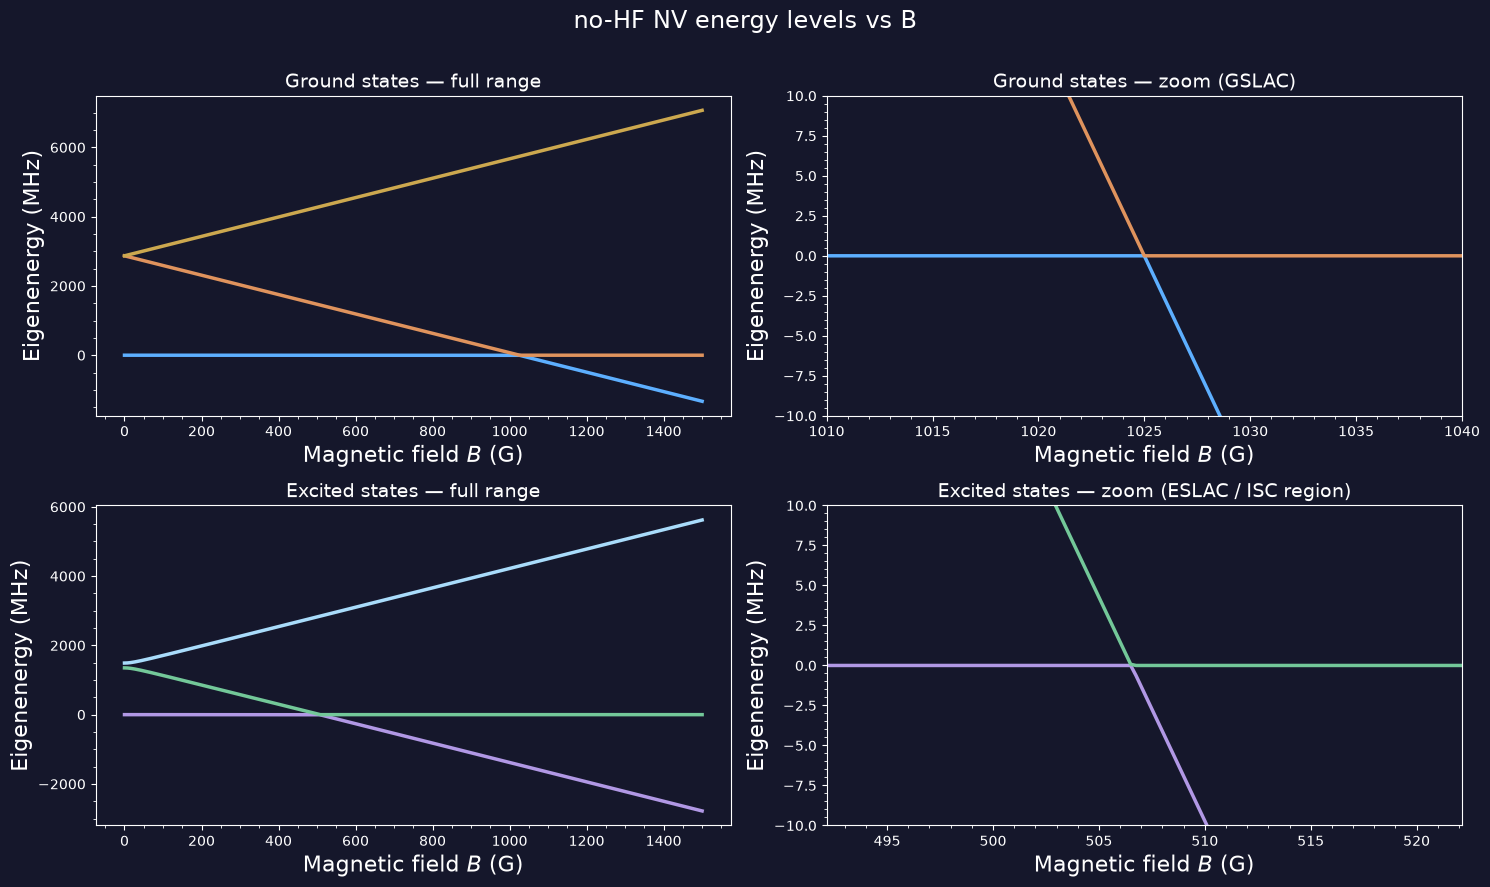

no-HF eigenstates (superpositions of the bare basis):
  B = 0.0 G
    GS: $|0\rangle$, $|{+}1\rangle$, $|{-}1\rangle$
    ES: $|0\rangle_e$, 0.707$|{+}1\rangle_e$ + 0.707$|{-}1\rangle_e$, 0.707$|{-}1\rangle_e$ + 0.707$|{+}1\rangle_e$
  B = 100.0 G
    GS: $|0\rangle$, $|{-}1\rangle$, $|{+}1\rangle$
    ES: $|0\rangle_e$, 0.993$|{-}1\rangle_e$ + 0.122$|{+}1\rangle_e$, 0.993$|{+}1\rangle_e$ + 0.122$|{-}1\rangle_e$
  B = 350.0 G
    GS: $|0\rangle$, $|{-}1\rangle$, $|{+}1\rangle$
    ES: $|0\rangle_e$, 0.999$|{-}1\rangle_e$, 0.999$|{+}1\rangle_e$
  B = 510.0 G
    GS: $|0\rangle$, $|{-}1\rangle$, $|{+}1\rangle$
    ES: $|{-}1\rangle_e$, $|0\rangle_e$, $|{+}1\rangle_e$
  B = 1025.0 G
    GS: $|0\rangle$, $|{-}1\rangle$, $|{+}1\rangle$
    ES: $|{-}1\rangle_e$, $|0\rangle_e$, $|{+}1\rangle_e$
  B = 1200.0 G
    GS: $|{-}1\rangle$, $|0\rangle$, $|{+}1\rangle$
    ES: $|{-}1\rangle_e$, $|0\rangle_e$, $|{+}1\rangle_e$


In [2]:
data = engine.run_or_load(
    "energy_levels_no-HF",
    lambda: engine.compute_energy_levels(FIELDS, model="no-HF"),
    recompute=RECOMPUTE,
)
engine.plot_energy_levels_result(data, save_as="energy_levels_no-HF.png")
plt.show()
show_state_table(data)

## Hyperfine: Doherty (Model 3) and Duarte (Model 2), 14-level

energy levels [Doherty]:   0%|          | 0/6001 [00:00<?, ?it/s]

computed + saved -> /home/arturvdom/Research/PhD-Quantum-Control/examples/RawData/example_energy_levels_Doherty/energy_levels_Doherty.npy
saved energy_levels_Doherty_dark_theme.png + energy_levels_Doherty_light_theme.png (presentation figures/ + examples/Figures/)


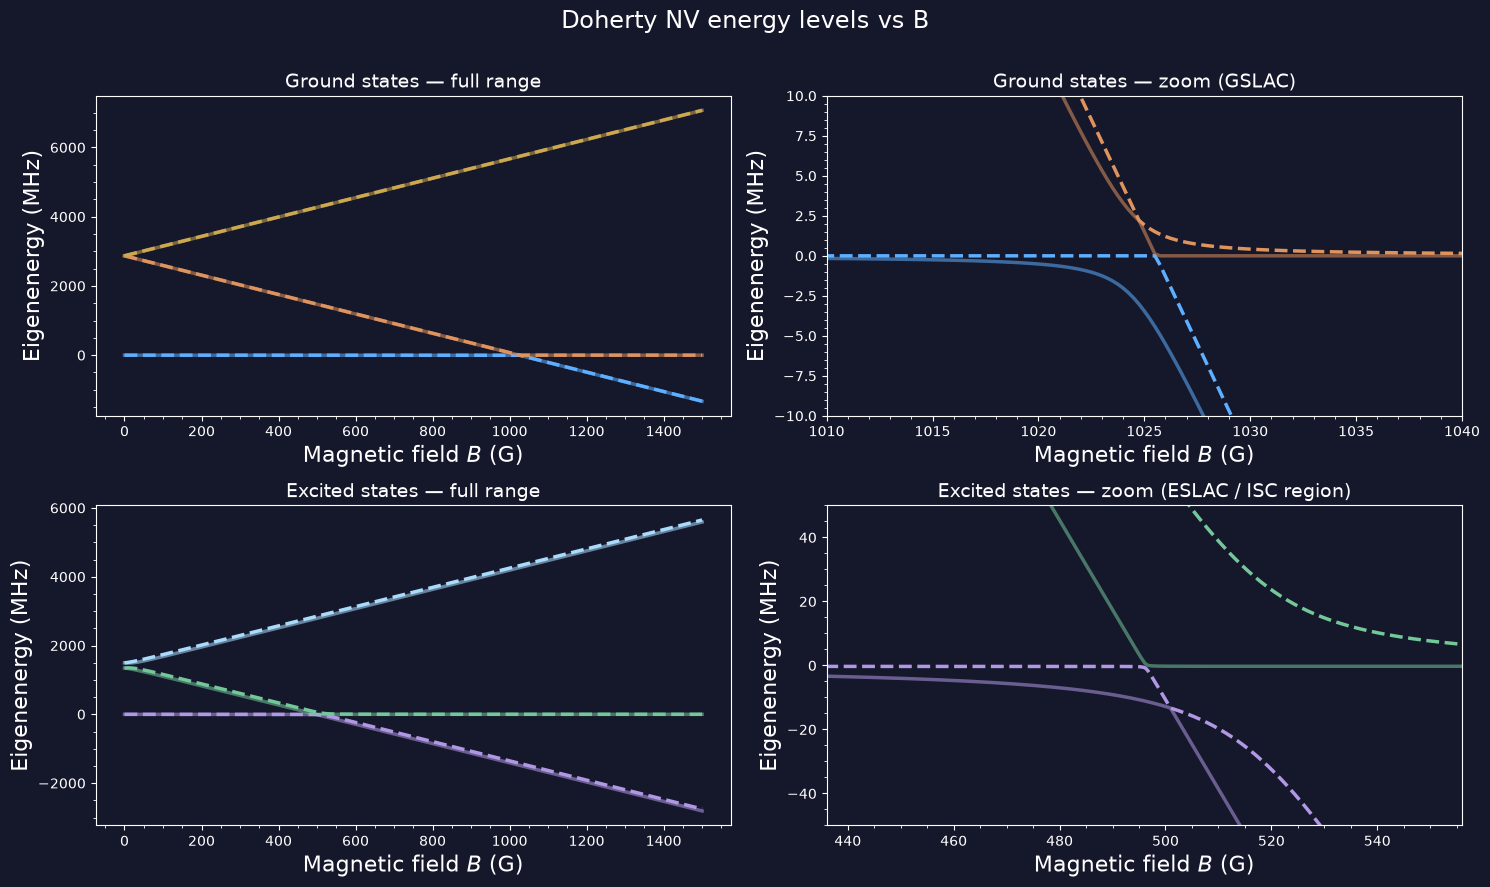

Doherty eigenstates (superpositions of the bare basis):
  B = 0.0 G
    GS: $|g_0\rangle$, $|g_1\rangle$, $|g_3\rangle$, $|g_4\rangle$, $|g_2\rangle$, $|g_5\rangle$
    ES: $|e_0\rangle$, $|e_1\rangle$, 0.832$|e_5\rangle$ + 0.555$|e_3\rangle$, 0.832$|e_2\rangle$ + 0.555$|e_4\rangle$, 0.832$|e_3\rangle$ + 0.555$|e_5\rangle$, 0.832$|e_4\rangle$ + 0.555$|e_2\rangle$
  B = 100.0 G
    GS: $|g_1\rangle$, $|g_0\rangle$, $|g_4\rangle$, $|g_5\rangle$, $|g_3\rangle$, $|g_2\rangle$
    ES: $|e_1\rangle$, $|e_0\rangle$, 0.994$|e_5\rangle$ + 0.111$|e_3\rangle$, 0.990$|e_4\rangle$ + 0.136$|e_2\rangle$, 0.991$|e_2\rangle$ + 0.136$|e_4\rangle$, 0.994$|e_3\rangle$ + 0.111$|e_5\rangle$
  B = 350.0 G
    GS: $|g_1\rangle$, $|g_0\rangle$, $|g_4\rangle$, $|g_5\rangle$, $|g_3\rangle$, $|g_2\rangle$
    ES: 0.998$|e_1\rangle$, $|e_0\rangle$, 0.999$|e_5\rangle$, 0.998$|e_4\rangle$, 0.999$|e_2\rangle$, 0.999$|e_3\rangle$
  B = 510.0 G
    GS: $|g_1\rangle$, $|g_0\rangle$, $|g_4\rangle$, $|g_5\rangle$, $|g_3\r

energy levels [Duarte]:   0%|          | 0/6001 [00:00<?, ?it/s]

computed + saved -> /home/arturvdom/Research/PhD-Quantum-Control/examples/RawData/example_energy_levels_Duarte/energy_levels_Duarte.npy
saved energy_levels_Duarte_dark_theme.png + energy_levels_Duarte_light_theme.png (presentation figures/ + examples/Figures/)


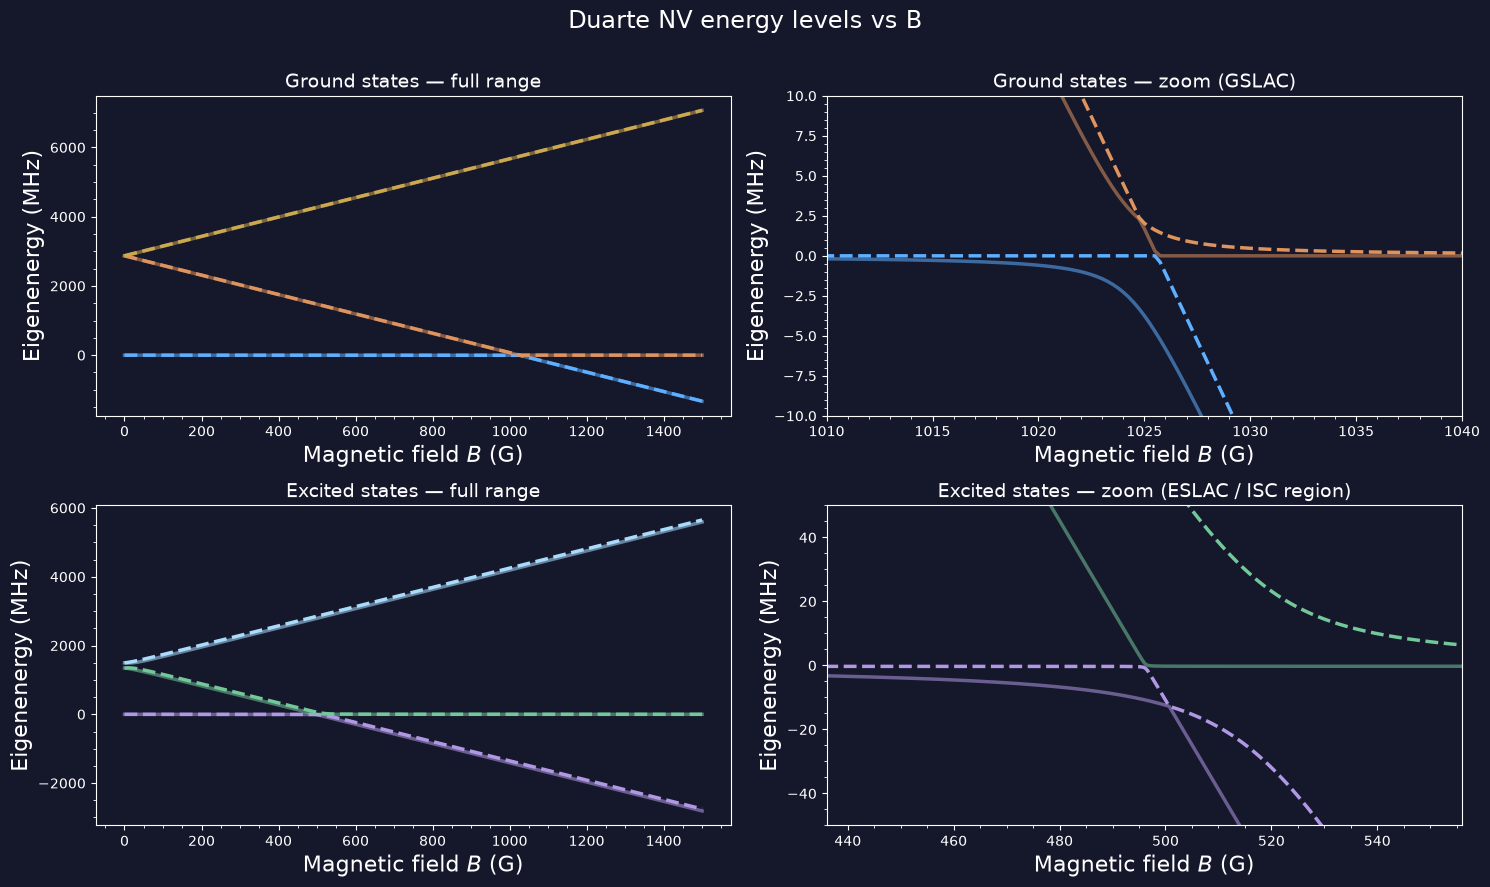

Duarte eigenstates (superpositions of the bare basis):
  B = 0.0 G
    GS: $|g_0\rangle$, $|g_1\rangle$, 0.993$|g_4\rangle$ + 0.122$|g_3\rangle$, 0.993$|g_3\rangle$ + 0.122$|g_4\rangle$, $|g_2\rangle$, $|g_5\rangle$
    ES: $|e_1\rangle$, $|e_0\rangle$, 0.832$|e_2\rangle$ + 0.554$|e_4\rangle$, 0.832$|e_5\rangle$ + 0.554$|e_3\rangle$, 0.832$|e_3\rangle$ + 0.554$|e_5\rangle$, 0.832$|e_4\rangle$ + 0.554$|e_2\rangle$
  B = 100.0 G
    GS: $|g_1\rangle$, $|g_0\rangle$, $|g_4\rangle$, $|g_5\rangle$, $|g_3\rangle$, $|g_2\rangle$
    ES: $|e_1\rangle$, $|e_0\rangle$, 0.994$|e_5\rangle$ + 0.111$|e_3\rangle$, 0.990$|e_4\rangle$ + 0.136$|e_2\rangle$, 0.991$|e_2\rangle$ + 0.136$|e_4\rangle$, 0.994$|e_3\rangle$ + 0.111$|e_5\rangle$
  B = 350.0 G
    GS: $|g_1\rangle$, $|g_0\rangle$, $|g_4\rangle$, $|g_5\rangle$, $|g_3\rangle$, $|g_2\rangle$
    ES: 0.998$|e_1\rangle$, $|e_0\rangle$, 0.999$|e_5\rangle$, 0.998$|e_4\rangle$, 0.999$|e_2\rangle$, 0.999$|e_3\rangle$
  B = 510.0 G
    GS: $|g_1\rangle$, $

In [3]:
for model in ["Doherty", "Duarte"]:
    data = engine.run_or_load(
        f"energy_levels_{model}",
        lambda m=model: engine.compute_energy_levels(FIELDS, model=m),
        recompute=RECOMPUTE,
    )
    engine.plot_energy_levels_result(data, save_as=f"energy_levels_{model}.png")
    plt.show()
    show_state_table(data)

## Energy levels vs field orientation (angle sweep)

So far the field was along the NV axis ($\theta=0$). Tilting the field by $\theta$ (the angle between $\vec B$ and the NV axis) mixes the $m_s$ levels even away from the anti-crossings, lifting degeneracies and bending the branches. Below we sweep $\theta\in\{0,90,120,180\}^\circ$ (with $\phi=0$) for the no-HF model.

These are **fast** (energy levels only), so they always recompute — no cache. Swap `model="no-HF"` for `"Doherty"`/`"Duarte"` to see the same for the 14-level hyperfine models.

energy levels [no-HF]:   0%|          | 0/6001 [00:00<?, ?it/s]

saved energy_levels_angle0_dark_theme.png + energy_levels_angle0_light_theme.png (presentation figures/ + examples/Figures/)


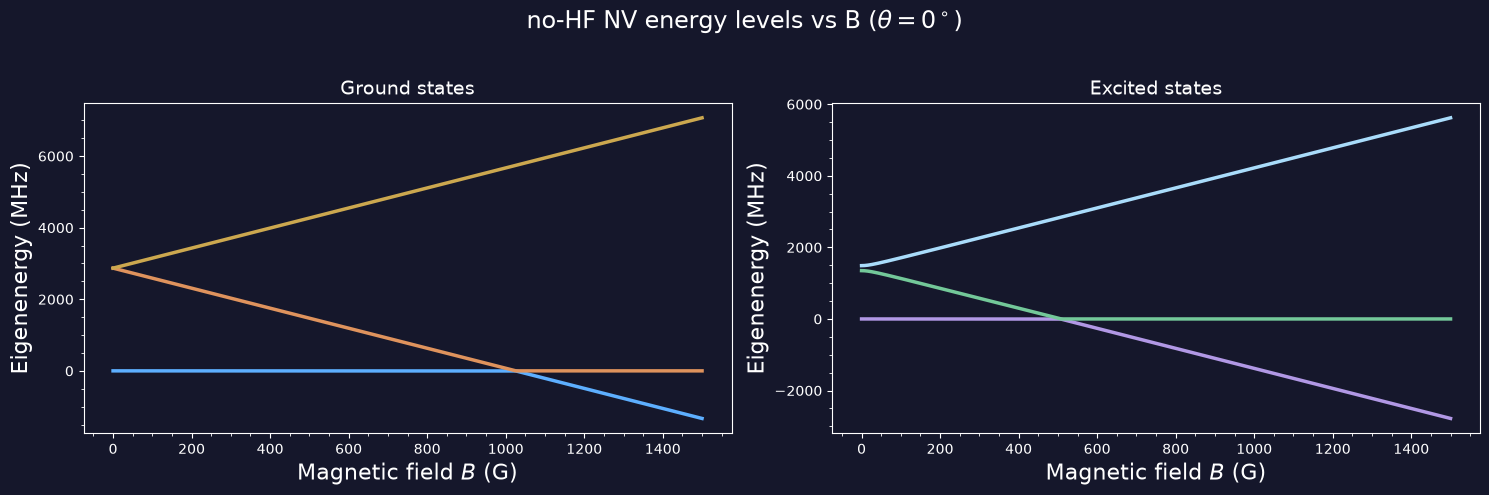

energy levels [no-HF]:   0%|          | 0/6001 [00:00<?, ?it/s]

saved energy_levels_angle90_dark_theme.png + energy_levels_angle90_light_theme.png (presentation figures/ + examples/Figures/)


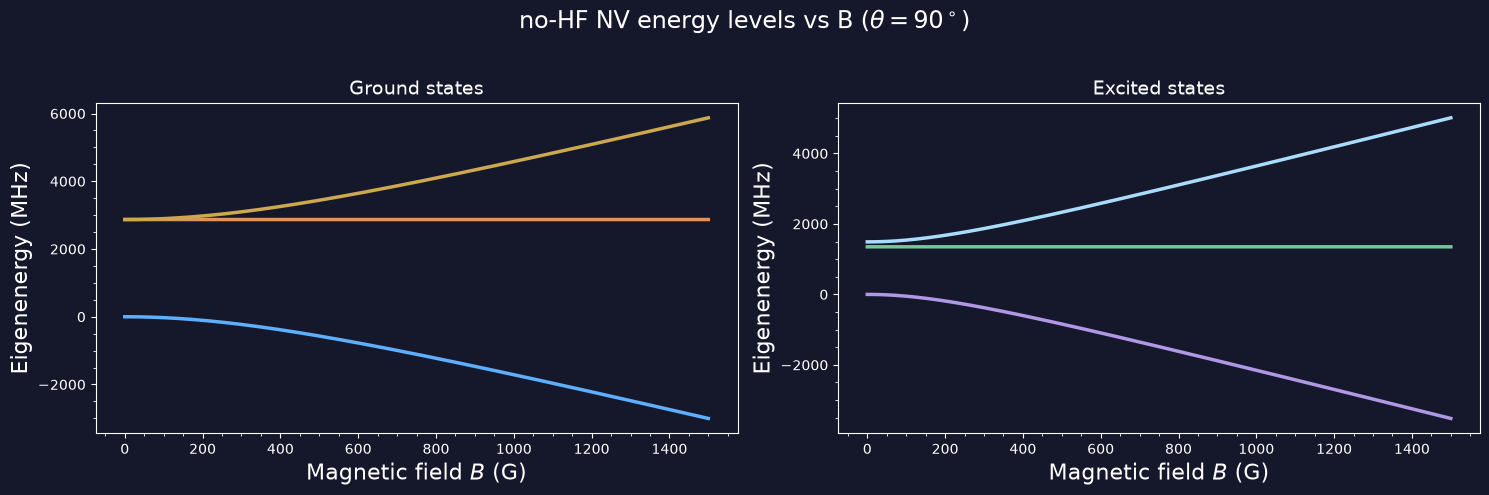

energy levels [no-HF]:   0%|          | 0/6001 [00:00<?, ?it/s]

saved energy_levels_angle120_dark_theme.png + energy_levels_angle120_light_theme.png (presentation figures/ + examples/Figures/)


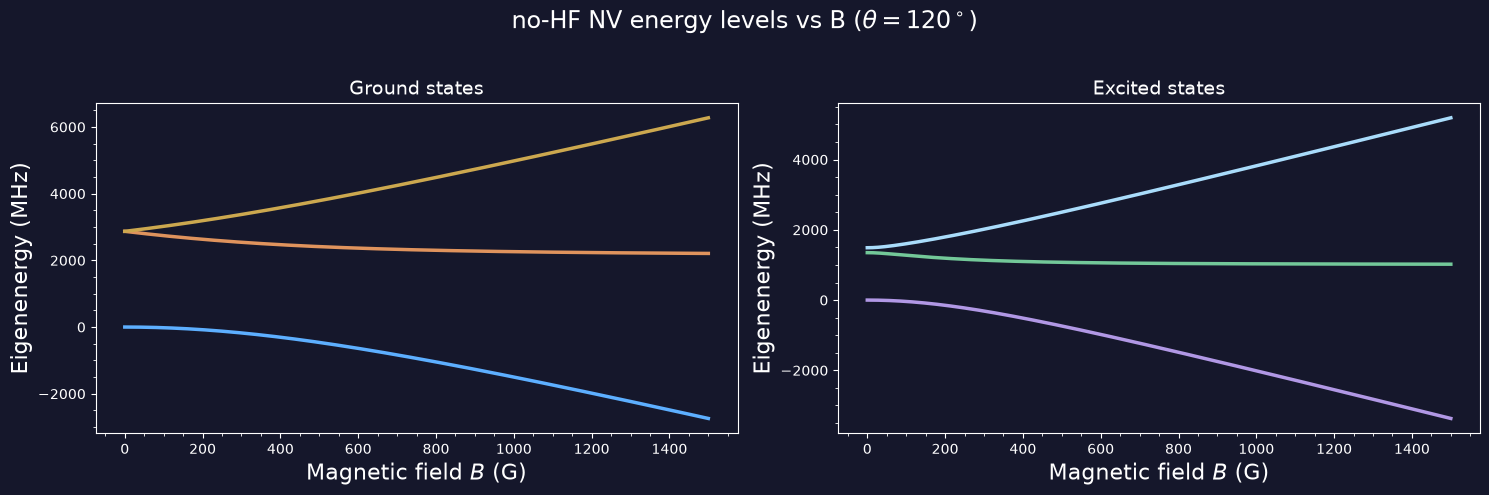

energy levels [no-HF]:   0%|          | 0/6001 [00:00<?, ?it/s]

saved energy_levels_angle180_dark_theme.png + energy_levels_angle180_light_theme.png (presentation figures/ + examples/Figures/)


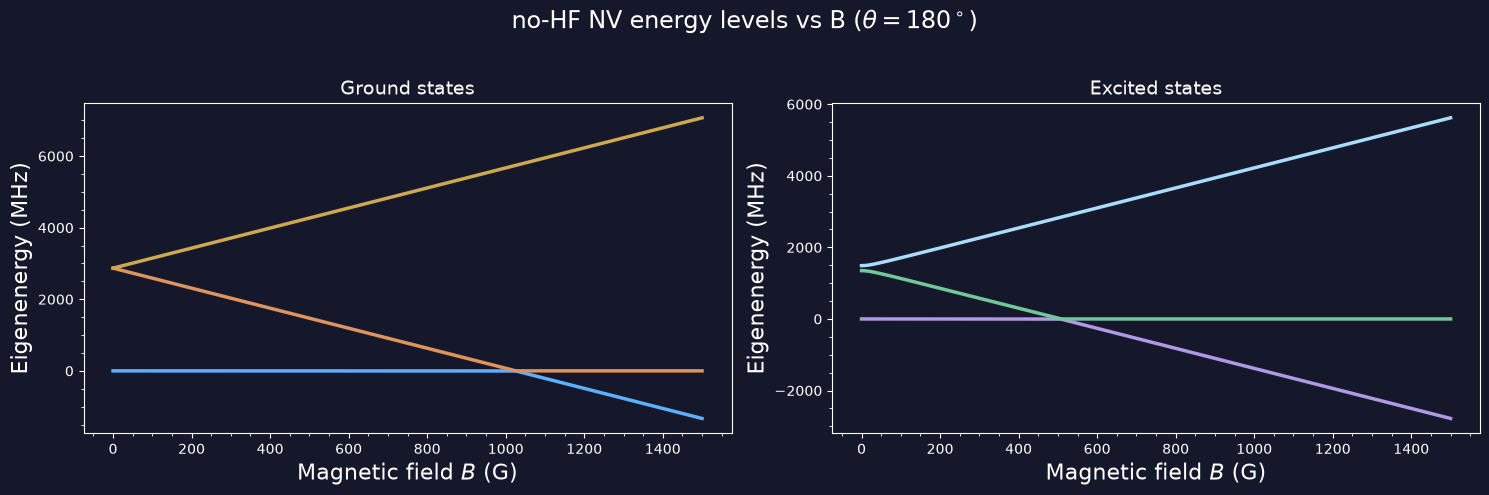

In [4]:
for angle in [0, 90, 120, 180]:  # theta in degrees; B-to-NV-axis angle
    data = engine.compute_energy_levels(FIELDS, model="no-HF", theta=np.deg2rad(angle))
    engine.plot_energy_levels_angle_result(data, angle, save_as=f"energy_levels_angle{angle}.png")
    plt.show()

In [5]:
# --- Smoke test: tiny self-contained run to confirm this notebook works ---
try:
    _d = engine.compute_energy_levels(np.linspace(0.0, 1500.0, 12), model="no-HF")
    engine.plot_energy_levels_result(_d, save_as=None)
    _da = engine.compute_energy_levels(np.linspace(0.0, 1500.0, 12), model="no-HF",
                                       theta=np.deg2rad(90))
    engine.plot_energy_levels_angle_result(_da, 90, save_as=None)
    # HF (14-level Doherty) energy levels — tiny
    _dhf = engine.compute_energy_levels(np.linspace(0.0, 1500.0, 12), model="Doherty")
    engine.plot_energy_levels_result(_dhf, save_as=None)
    plt.close("all")
    print("SMOKE OK: energy levels / angle / HF")
except Exception as _e:
    print("SMOKE FAIL:", repr(_e))

energy levels [no-HF]:   0%|          | 0/12 [00:00<?, ?it/s]

energy levels [no-HF]:   0%|          | 0/12 [00:00<?, ?it/s]

energy levels [Doherty]:   0%|          | 0/12 [00:00<?, ?it/s]

SMOKE OK: energy levels / angle / HF
